# Level 2 - Task 4: Restaurant Chains Analysis

## Objective

The objective of this task is to identify restaurant chains in the dataset and analyze their performance.

### This task includes:

- Identifying restaurant chains.
- Determining the most common restaurant chains.
- Calculating the average ratings of restaurant chains.
- Comparing the popularity of restaurant chains.

### Libraries Used

- Pandas
- Matplotlib
- Seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Dataset
df = pd.read_csv("../Dataset.csv")

## Step 1: Identify Restaurant Chains

Restaurant chains are identified by finding restaurant names that appear more than once in the dataset.

In [5]:
restaurant_counts = df["Restaurant Name"].value_counts()

chains = restaurant_counts[restaurant_counts > 1]

print("Number of Restaurant Chains:", len(chains))

Number of Restaurant Chains: 734


## Step 2: Display the Top Restaurant Chains

The most frequently occurring restaurant chains are displayed.

In [8]:
chains.head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

## Step 3: Create Summary Table

A summary table is created showing the most common restaurant chains.

In [11]:
summary = pd.DataFrame({
    "Restaurant Chain": chains.head(10).index,
    "Number of Outlets": chains.head(10).values
})

summary

,Restaurant Chain,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


## Step 4: Visualize Restaurant Chains

The following chart shows the restaurant chains with the highest number of outlets.

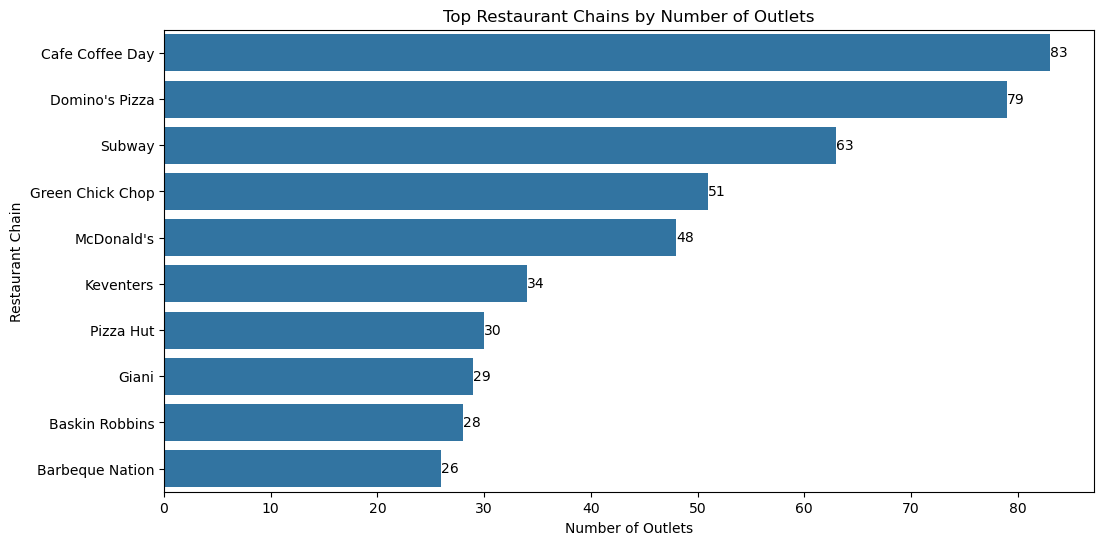

In [14]:
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=summary,
    x="Number of Outlets",
    y="Restaurant Chain"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top Restaurant Chains by Number of Outlets")
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Chain")

plt.savefig(
    "../images/top_restaurant_chains.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5: Calculate Average Ratings of Restaurant Chains

The average rating is calculated for each restaurant chain.

In [17]:
chain_ratings = (
    df.groupby("Restaurant Name")
    .agg({
        "Restaurant ID":"count",
        "Aggregate rating":"mean"
    })
)

chain_ratings.columns = [
    "Number of Outlets",
    "Average Rating"
]

chain_ratings = chain_ratings[
    chain_ratings["Number of Outlets"] > 1
]

chain_ratings = chain_ratings.sort_values(
    by="Average Rating",
    ascending=False
)

chain_ratings.head(10)

,Number of Outlets,Average Rating
Restaurant Name,,
Talaga Sampireun,3,4.900
Silantro Fil-Mex,2,4.850
AB's Absolute Barbecues,2,4.850
AB's - Absolute Barbecues,4,4.825
Naturals Ice Cream,2,4.800
Gymkhana,2,4.700
The Cheesecake Factory,2,4.650
Dishoom,2,4.600
Garota de Ipanema,2,4.600


## Step 6: Compare Ratings of Popular Chains

To ensure meaningful comparisons, only chains with at least 5 outlets are considered.

In [20]:
popular_chains = chain_ratings[
    chain_ratings["Number of Outlets"] >= 5
]

popular_chains = popular_chains.sort_values(
    by="Average Rating",
    ascending=False
)

popular_chains.head(10)

,Number of Outlets,Average Rating
Restaurant Name,,
Chili's,5,4.580000
Farzi Cafe,6,4.366667
Barbeque Nation,26,4.353846
Punjab Grill,5,4.340000
Mocha,7,4.185714
Happy Hakka,5,3.860000
Texas Roadhouse,5,3.860000
TGI Friday's,6,3.850000
L'Opera,5,3.820000


## Step 7: Visualize Average Ratings

The chart below compares the average ratings of popular restaurant chains.

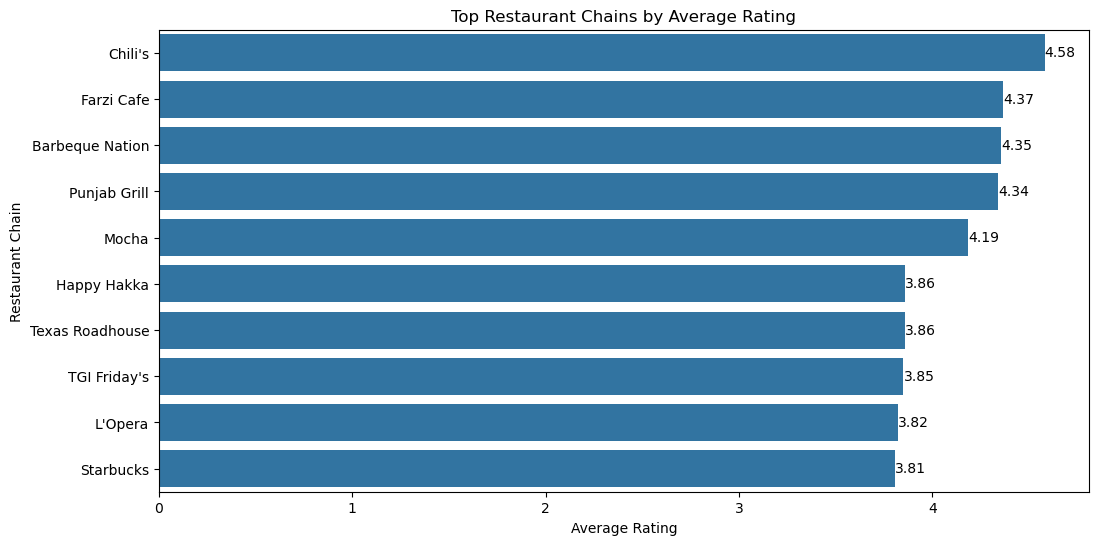

In [23]:
top_rating = popular_chains.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_rating["Average Rating"],
    y=top_rating.index
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Top Restaurant Chains by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Chain")

plt.savefig(
    "../images/top_chain_ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insight

- Restaurant chains with more outlets generally have stronger brand recognition.
- Some chains maintain high customer ratings despite operating many outlets.
- Businesses can study these successful chains to improve consistency and customer satisfaction.
- Expanding a restaurant chain should focus on maintaining food quality and service standards.

# Conclusion

## Key Findings

- Restaurant chains were identified using restaurant names.
- The most common chains were analyzed based on the number of outlets.
- Average ratings were calculated for restaurant chains.
- Popular chains with high ratings demonstrate successful business strategies and consistent customer satisfaction.

Restaurant chain analysis helps understand brand performance, market presence, and customer preferences.